In [20]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.rfm_features import compute_rfm
import pandas as pd

df = pd.read_csv("../data/processed/feature_retail.csv")

df["invoice_date"] = pd.to_datetime(df["invoice_date"])

rfm = compute_rfm(df)

rfm.describe()

2026-03-09 20:52:53,447 - INFO - Computing RFM metrics


,customer_id,recency,frequency,monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,91.518322,4.271952,2053.793018
std,1721.889758,100.009747,7.705493,8988.248381
min,12346.000000,0.000000,1.000000,0.000000
25%,13812.500000,17.000000,1.000000,307.245000
50%,15299.000000,50.000000,2.000000,674.450000
75%,16778.500000,141.000000,5.000000,1661.640000
max,18287.000000,373.000000,210.000000,280206.020000


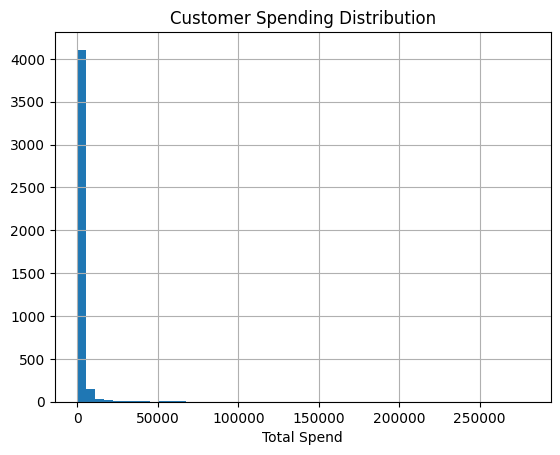

In [7]:
import matplotlib.pyplot as plt

rfm["monetary"].hist(bins=50)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.show()

In [10]:
rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1])
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["m_score"] = pd.qcut(rfm["monetary"],4, labels=[1,2,3,4])

In [11]:
rfm["rfm_score"] = (
    rfm["r_score"].astype(str)
    + rfm ["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
12346.0,325,1,77183.60,1,1,4,114
12347.0,1,7,4310.00,4,4,4,444
12348.0,74,4,1797.24,2,3,4,234
12349.0,18,1,1757.55,3,1,4,314
12350.0,309,1,334.40,1,1,2,112


In [12]:
rfm[rfm["rfm_score"] == "444"].head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
12347.0,1,7,4310.00,4,4,4,444
12362.0,2,10,5226.23,4,4,4,444
12388.0,15,6,2780.66,4,4,4,444
12417.0,2,9,3649.10,4,4,4,444
12423.0,0,8,1859.31,4,4,4,444


In [13]:
rfm["segment"] = "regular"

rfm.loc[rfm["rfm_score"] == "444", "segment"] = "champions"
rfm.loc[rfm["f_score"].astype(int) >=3, "segment"] = "loyal"
rfm.loc[rfm["f_score"].astype(int) <=2, "segment"] = "at_risk"

In [14]:
rfm.to_csv("../data/processed/rfm_customers.csv")